# Coding Strategy: A Step-By-Step Demonstration of the Implementation of the Leakage Resistant Pipeline

<div style="text-align: center;"> <img src = "res/Images/Pipeline - Overview.jpg" width="75%"/> </div>


A minimal, runnable demonstration of the seven-step, leakage-resistant pipeline from
**Chapter 2 (Figure 2-1)**, implemented the way **Chapter 3 (§3.3–§3.8)** describes. Each section
below shows the bare minimum code needed to demonstrate one step of the pipeline.

The task is **violent recidivism forecasting**: for each convicted offender at the time of their
disposition, predict whether they commit a violent offence within the next three years.

| Figure 2-1 step | Section | Leakage addressed |
|---|---|---|
| 1. Dataset download | 1 | — |
| 2. Stateless preprocessing | 2 | Temporal, Target |
| 3–4. Cross-validation prep & assignment | 3 | **Group** |
| 5. State-dependent preprocessing | 4 | Preprocessing |
| 6. Model building / hyperparameter tuning | 5 | Hyperparameter |
| 7. Evaluation on the held-out test set | 6 | — |

Because the real PNC data is confidential, <strong>1 | Step One: Dataset Download </strong> generates a synthetic dataset to stand in for
it. The dataset carries the bare minimum of features needed to exercise every step, and is tuned to
reproduce the paper's ~30% violent-recidivism rate while still supporting a high-performing model.

We now go step-by-step, illustrating how each step of the pipeline is implemented

## 0 | Import Libraries

In [1]:
%matplotlib inline
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, fbeta_score, make_scorer,
                             confusion_matrix, precision_recall_curve, roc_auc_score,
                             auc, average_precision_score)

# Constants
RANDOM_STATE = 42                            # one seed everywhere, so results are reproducible
LABEL_COLUMN = "violent_recidivism_3y"       # the single label we forecast
NUMBER_OF_FOLDS = 5                           # k for k-fold cross-validation
RAW_DATASET_PATH = "res/pnc_demo_raw.csv"    # where the downloaded dataset lives
FOLD_DIR = "res/dataset_folds"               # where the 5 fold CSVs are saved

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
np.random.seed(RANDOM_STATE)

## 1 | Step One: Dataset Download

<div style="text-align: center;"> <img src = "res/Images/Pipeline - Step 1.jpg" width="80%"/> </div>

**Technique: select the unit of analysis.** Here the unit of analysis is *a convicted offender at
the time of their disposition*, so predictions are only issued after a disposition. Each row is one
conviction (one offence at one court date), and an offender (`PersonID`) can appear across several
rows over time.

We generate a synthetic dataset with the same shape as the real PNC records, write it to disk, then
"download" it by reading it back. The download is exactly as Step One would read a real database. The generator
emits only raw, observed columns; the label and engineered features are built later, in Step Two.


In [2]:
# Builds a synthetic PNC-like dataset to stand in for the real (confidential) conviction records.
# Each row is one conviction (one offence at one court date); an offender (PersonID) can appear many times.
def generate_dummy_dataset(number_of_offenders = 4000, seed = RANDOM_STATE):

    random_generator = np.random.default_rng(seed)

    # The PNC records were made available to the research team on 3 February 2011, so no conviction in the
    # dataset can be dated later than this (see paper, §3.3).
    earliest_date, latest_date = pd.Timestamp("2000-01-01"), pd.Timestamp("2011-02-03")
    raw_ethnicities = ["White - North European", "White - South European", "Black", "Asian",
                       "Chinese  Japanese or S E Asian", "Middle Eastern", "Unknown"]
    non_violent_offences = ["sexual", "drugs", "theft", "fraud", "public_order"]

    rows = []
    for offender_id in range(number_of_offenders):

        # Each synthetic offender has a hidden 'criminality' trait that drives their whole record. A small number of
        # high-risk individuals reoffend often and violently so the dataset has a learnable signal.
        is_high_risk = random_generator.random() < 0.11
        criminality = random_generator.beta(8.0, 2.0) if is_high_risk else random_generator.beta(2.0, 10.0)

        # Higher criminality -> more convictions, and a younger age at the first offence
        number_of_convictions = min(1 + random_generator.poisson((6.0 if is_high_risk else 1.2) * criminality + 0.2), 14)
        age_at_first_offence = int(np.clip(random_generator.normal(30 - 14 * criminality, 4), 12, 70))
        ethnicity = random_generator.choice(raw_ethnicities, p=[0.62, 0.06, 0.13, 0.09, 0.03, 0.03, 0.04])

        # Spread this offender's convictions out over a stretch of years
        active_years = 365 * (2 if is_high_risk else 3)
        first_offence_date = earliest_date + pd.to_timedelta(
            int(random_generator.integers(0, (latest_date - earliest_date).days - active_years)), unit="D")
        day_offsets = np.sort(random_generator.integers(45, active_years, size=number_of_convictions))
        day_offsets = day_offsets - day_offsets.min()

        for offset in day_offsets:
            court_date = first_offence_date + pd.to_timedelta(int(offset), unit="D")
            age = int(round(age_at_first_offence + (court_date - first_offence_date).days / 365.25))

            # Higher criminality -> the offence is more likely to be violent
            offence_is_violent = random_generator.random() < (0.05 + 0.75 * criminality)
            offence_type = "violence" if offence_is_violent else random_generator.choice(
                non_violent_offences, p=[.08, .30, .34, .14, .14])

            # A violent offence sometimes involves a weapon (incl. a couple of very rare ones)
            if offence_is_violent and random_generator.random() < (0.25 + 0.5 * criminality):
                weapon = random_generator.choice(["knife", "firearm", "blunt_object", "explosives", "crossbow"],
                                                 p=[0.55, 0.25, 0.17, 0.02, 0.01])
            else:
                weapon = "none"

            # One conviction = one row (no simultaneous offences in this demo dataset)
            rows.append(dict(PersonID = offender_id,
                             CourtDate = court_date,
                             AgeAtDisposition = age,
                             EthnicityDescription = ethnicity,
                             OffenceType = offence_type,
                             OffenceInvolvedWeapon = weapon,
                             # AddressPostCode is missing for most rows (we delete it in Section 2.1)
                             AddressPostCode = (f"AB{random_generator.integers(1, 99)} {random_generator.integers(1, 9)}XY"
                                                if random_generator.random() < 0.12 else np.nan)))

    df = pd.DataFrame(rows)

    # Make ~4% of ethnicity values genuinely missing (blank)
    rows_with_missing_ethnicity = random_generator.random(len(df)) < 0.04
    df.loc[rows_with_missing_ethnicity, "EthnicityDescription"] = np.nan

    # Shuffle so the dataset doesn't arrive in a tidy order
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

dummy_dataset = generate_dummy_dataset()
os.makedirs(os.path.dirname(RAW_DATASET_PATH), exist_ok=True)  # create res/ if it isn't there yet (e.g. a fresh Colab runtime)
dummy_dataset.to_csv(RAW_DATASET_PATH, index=False)
print(f"Wrote synthetic dataset: {dummy_dataset.shape[0]:,} rows x {dummy_dataset.shape[1]} columns -> {RAW_DATASET_PATH}")

Wrote synthetic dataset: 7,648 rows x 7 columns -> res/pnc_demo_raw.csv


In [3]:
# "Download" the dataset = read it back in (the only thing Step One actually does)
df = pd.read_csv(RAW_DATASET_PATH, parse_dates=["CourtDate"])

print(f"Downloaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Unique offenders (PersonID): {df['PersonID'].nunique():,}")
df.head()

Downloaded dataset: 7,648 rows x 7 columns
Unique offenders (PersonID): 4,000


,PersonID,CourtDate,AgeAtDisposition,EthnicityDescription,OffenceType,OffenceInvolvedWeapon,AddressPostCode
0,1705,2006-04-22,22,White - North European,violence,none,NaN
1,3066,2005-12-12,22,Unknown,violence,knife,NaN
2,1496,2000-07-29,27,White - North European,theft,none,NaN
3,2060,2004-05-22,29,White - North European,violence,firearm,AB90 5XY
4,624,2008-10-24,18,White - North European,drugs,none,NaN


## 2 | Step Two: Stateless Preprocessing

<div style="text-align: center;"> <img src = "res/Images/Pipeline - Step 2.jpg" width="80%"/> </div>

Stateless preprocessing transforms each row independently of every other row, so it can safely be
applied to the whole dataset *before* partitioning: nothing crosses a train/test boundary that has
not been drawn yet. Following Chapter 3 (§3.4), it runs in four stages:

- **2.1** stateless handling of missing data
- **2.2** feature engineering (including building the label)
- **2.3** data (row) exclusions
- **2.4** consolidation of sparse categorical levels

The two leakage concerns guarded here are **target leakage** (keep only one label) and **temporal
leakage** (a feature may only use information available at or before the moment of prediction).

### 2.1 | Stateless Handling of Missing Data

We first inspect the data to see *where* and *why* values are missing, then apply two of the paper's
simple stateless fixes: **deleting** a feature that is mostly missing, and **filling** missing
entries with a **dummy value**.

In [4]:
# Inspect missingness across every column
percent_missing = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Missing values per column (%):")
print(percent_missing.to_string())

Missing values per column (%):
AddressPostCode          88.55
EthnicityDescription      3.83
PersonID                  0.00
AgeAtDisposition          0.00
CourtDate                 0.00
OffenceType               0.00
OffenceInvolvedWeapon     0.00


In [5]:
# Inspect ethnicity on its own. value_counts(dropna=False) reveals the NaN (truly-missing) bucket,
# which is separate from the literal "Unknown" category the data provider already records.
df["EthnicityDescription"].value_counts(dropna=False)

EthnicityDescription
White - North European            4716
Black                              897
Asian                              564
White - South European             473
Unknown                            313
NaN                                293
Middle Eastern                     217
Chinese  Japanese or S E Asian     175
Name: count, dtype: int64

In [6]:
# (a) DELETE A FEATURE: AddressPostCode is missing for the vast majority of rows, so we drop it. This is
#     stateless -- the decision is about the column as a whole, not learned from other rows. We print the
#     full column list before and after to confirm the feature is gone.
print(f"AddressPostCode is {df['AddressPostCode'].isna().mean() * 100:.1f}% missing -> deleting the feature\n")
print("Columns BEFORE deletion:")
print(list(df.columns))

df = df.drop(columns=["AddressPostCode"])

print("\nColumns AFTER deletion:")
print(list(df.columns))

# (b) FILL WITH A DUMMY VALUE: replace the genuinely-missing ethnicity entries with "Unknown". This is
#     stateless -- every NaN maps to the same constant, independent of any other row.
number_missing = df["EthnicityDescription"].isna().sum()
df["EthnicityDescription"] = df["EthnicityDescription"].fillna("Unknown")
print(f"\nFilled {number_missing:,} missing ethnicity values with the dummy value 'Unknown'")
df["EthnicityDescription"].value_counts()

AddressPostCode is 88.5% missing -> deleting the feature

Columns BEFORE deletion:
['PersonID', 'CourtDate', 'AgeAtDisposition', 'EthnicityDescription', 'OffenceType', 'OffenceInvolvedWeapon', 'AddressPostCode']

Columns AFTER deletion:
['PersonID', 'CourtDate', 'AgeAtDisposition', 'EthnicityDescription', 'OffenceType', 'OffenceInvolvedWeapon']

Filled 293 missing ethnicity values with the dummy value 'Unknown'


EthnicityDescription
White - North European            4716
Black                              897
Unknown                            606
Asian                              564
White - South European             473
Middle Eastern                     217
Chinese  Japanese or S E Asian     175
Name: count, dtype: int64

### 2.2 | Feature Engineering

We build the features the model will learn from, and the label it will predict, in three stages:

- **2.2.1** simple within-row features
- **2.2.2** criminal-history features
- **2.2.3** label construction

**Temporal leakage.** Criminal-history features borrow information across an offender's records, which
is only allowed when that information lies in the *past*. Every history feature below is computed from
strictly *earlier* court dates, so a prediction never peeks into the future.

**Target leakage.** Two labels could be built (general and violent recidivism); keeping both would let
the model use one as a near-perfect proxy for the other. We build and keep **only** the violent label
(see Section 2.2.3).

#### 2.2.1 | Simple Within-Row Feature Engineering

These features are read straight off the current row, so they need no information from any other record
and carry no leakage risk.

In [7]:
# Did this offence involve a weapon? (read straight from the current row)
df["has_weapon"] = (df["OffenceInvolvedWeapon"] != "none").astype(int)

# Risk band from the age-crime curve: younger offenders are higher risk (read from the current row)
# Note that the paper uses slightly different values based on Bindler & Hjalmarsson (2017) (see Appendix C: §2.6.3)
df["age_crime_risk"] = pd.cut(df["AgeAtDisposition"], bins=[0, 25, 40, 200],
                              labels=["High", "Medium", "Low"]).astype(str)

# Outputs the dataset with our new features
df[["AgeAtDisposition", "age_crime_risk", "OffenceInvolvedWeapon", "has_weapon"]].head()

,AgeAtDisposition,age_crime_risk,OffenceInvolvedWeapon,has_weapon
0,22,High,none,0
1,22,High,knife,1
2,27,Medium,none,0
3,29,Medium,firearm,1
4,18,High,none,0


#### 2.2.2 | Criminal History

These features summarise each offender's *past* convictions. Because the logic walks each offender's
records in date order, we first sort the dataframe and then run a sanity check to confirm the ordering
is correct — the temporal-leakage guarantee depends on it.

In [8]:
# Sort so each offender's convictions are in chronological order (earliest -> latest).
# The criminal-history features (2.2.2) and the label (2.2.3) both rely on this ordering.
df = df.sort_values(["PersonID", "CourtDate"]).reset_index(drop=True)

In [9]:
# Sanity check: the dataframe must be sorted by offender, then by date (earliest -> latest). The history
# and label logic below assumes this, so we assert it explicitly rather than just trusting the sort.
assert df["PersonID"].is_monotonic_increasing, "PersonID is not in ascending order"

dates_sorted_within_each_offender = df.groupby("PersonID")["CourtDate"].apply(
    lambda offender_dates: offender_dates.is_monotonic_increasing).all()
assert dates_sorted_within_each_offender, "CourtDate is not earliest -> latest within every offender"

print("Sanity check passed: rows are sorted by offender, then by court date (earliest -> latest).\n")
print("Head of the sorted dataset. Note that dates are in YYYY-MM-DD:")
df.head()

Sanity check passed: rows are sorted by offender, then by court date (earliest -> latest).



Head of the sorted dataset. Note that dates are in YYYY-MM-DD:


,PersonID,CourtDate,AgeAtDisposition,EthnicityDescription,OffenceType,OffenceInvolvedWeapon,has_weapon,age_crime_risk
0,0,2006-10-18,28,White - North European,theft,none,0,Medium
1,0,2006-12-10,28,White - North European,drugs,none,0,Medium
2,1,2003-05-16,19,Black,violence,knife,1,High
3,1,2003-06-13,19,Black,violence,firearm,1,High
4,1,2003-07-13,19,Black,theft,none,0,High


In [10]:
# Builds each offender's criminal history as of each conviction. For every row it looks back over that
# SAME offender's earlier convictions and summarises them. Because it only ever looks at strictly earlier
# court dates, a feature can never use information from the future (temporal leakage).
#
# Assumes the dataframe is already sorted by [PersonID, CourtDate] (see the sort + sanity check above),
# so within each offender the rows run earliest -> latest.
#
# Creates three features:
#   prior_conviction_count    -> how many convictions the offender had BEFORE this one
#   prior_violent_count       -> how many of those prior convictions were violent
#   age_of_first_disposition  -> the offender's age at their very first conviction
def add_criminal_history_features(df):

    # We fill these arrays in one row at a time (one entry per row of the dataframe)
    prior_conviction_count = np.zeros(len(df), dtype=int)
    prior_violent_count = np.zeros(len(df), dtype=int)

    # Work through each offender separately. row_positions are the row numbers belonging to this
    # offender, already in date order because the dataframe is sorted.
    for offender_id, row_positions in df.groupby("PersonID").indices.items():
        court_dates = df["CourtDate"].values[row_positions]
        offence_was_violent = (df["OffenceType"].values[row_positions] == "violence")

        # Go through each of this offender's convictions in turn
        for position_in_offender, row in enumerate(row_positions):
            this_court_date = court_dates[position_in_offender]

            # Which of this offender's convictions happened STRICTLY BEFORE the current one?
            happened_before = court_dates < this_court_date

            # Count those past convictions, and how many of them were violent
            prior_conviction_count[row] = happened_before.sum()
            prior_violent_count[row] = (happened_before & offence_was_violent).sum()

    df["prior_conviction_count"] = prior_conviction_count
    df["prior_violent_count"] = prior_violent_count

    # Age of first disposition = the youngest age we ever see for that offender
    df["age_of_first_disposition"] = df.groupby("PersonID")["AgeAtDisposition"].transform("min")

    return df

In [11]:
df = add_criminal_history_features(df)
print("Added criminal-history features.")
df[["PersonID", "CourtDate", "OffenceType", "prior_conviction_count",
    "prior_violent_count", "age_of_first_disposition"]].head(8)

Added criminal-history features.


,PersonID,CourtDate,OffenceType,prior_conviction_count,prior_violent_count,age_of_first_disposition
0,0,2006-10-18,theft,0,0,28
1,0,2006-12-10,drugs,1,0,28
2,1,2003-05-16,violence,0,0,19
3,1,2003-06-13,violence,1,1,19
4,1,2003-07-13,theft,2,2,19
5,1,2004-02-27,fraud,3,2,19
6,1,2004-06-27,violence,4,2,19
7,1,2004-07-28,violence,5,3,19


#### 2.2.3 | Label Construction

The label is the one thing that looks *forward* in time. We build only a **single** label — violent
recidivism — which is also how **target leakage** is addressed. Target leakage happens when a second
label (e.g. general recidivism) is left in the feature set and the model uses it as a near-perfect proxy
for the answer. Because this dataset only ever contains **one** label at a time, there is no second
label that could leak.

In [12]:
# Builds the label: for each conviction it looks FORWARD over that SAME offender's later convictions and
# flags whether any of them is violent within the next few years. Because it only ever looks at strictly
# LATER court dates, the label is purely prospective -- it never defines itself using the past or present,
# only the future.
#
# Assumes the dataframe is already sorted by [PersonID, CourtDate] (see the sort + sanity check above),
# so within each offender the rows run earliest -> latest.
#
# Creates one feature:
#   violent_recidivism_3y -> 1 if the offender is reconvicted of a violent offence within follow_up_years
#                            of this conviction, else 0
def build_violent_recidivism_label(df, follow_up_years = 3):

    # How far forward we are allowed to look (the measurement window)
    follow_up_window = np.timedelta64(follow_up_years * 365, "D")

    # We fill this array in one row at a time (one entry per row of the dataframe)
    label = np.zeros(len(df), dtype=int)

    # Work through each offender separately. row_positions are the row numbers belonging to this
    # offender, already in date order because the dataframe is sorted.
    for offender_id, row_positions in df.groupby("PersonID").indices.items():
        court_dates = df["CourtDate"].values[row_positions]
        offence_was_violent = (df["OffenceType"].values[row_positions] == "violence")

        # Go through each of this offender's convictions in turn
        for position_in_offender, row in enumerate(row_positions):
            this_court_date = court_dates[position_in_offender]

            # Which of this offender's convictions happened STRICTLY AFTER the current one, but still
            # within the follow-up window?
            within_follow_up = (court_dates > this_court_date) & (court_dates <= this_court_date + follow_up_window)

            # The offender reoffends violently if any of those FUTURE convictions was violent
            label[row] = int((within_follow_up & offence_was_violent).any())

    return label

# Build and keep ONLY this one label -- keeping a single label is what prevents target leakage
df[LABEL_COLUMN] = build_violent_recidivism_label(df)
print(f"Built the (single) violent-recidivism label | prevalence so far: {df[LABEL_COLUMN].mean() * 100:.1f}%")
print(f"The prevalence in Chapter 3 was around 29%.")

Built the (single) violent-recidivism label | prevalence so far: 30.7%
The prevalence in Chapter 3 was around 29%.


In [13]:
# Sanity-check that the label is truly PROSPECTIVE -- i.e. it only
# ever looks FORWARD (up to three years) into the future. A direct consequence of looking only forward is
# that an offender's most RECENT conviction can never carry a positive label: there are no later
# convictions after it for the label to look at. We assert exactly that.
final_conviction_per_offender = df.groupby("PersonID").tail(1)
assert (final_conviction_per_offender[LABEL_COLUMN] == 0).all(), \
    "An offender's final conviction has a positive label -- the label is not purely prospective!"
print("Sanity check passed: every offender's final conviction has label 0 (the label only looks forward).")

print()
print("*"*20)
print("Head of the dataset with the new label")
print("Remember - the label shoudl only be '1' (True) "
      "if (a) within 3 years into the future (CourtDate) an individual (b) committed a violent offence (OffenceType = violence)")
df.head(10)

Sanity check passed: every offender's final conviction has label 0 (the label only looks forward).

********************
Head of the dataset with the new label
Remember - the label shoudl only be '1' (True) if (a) within 3 years into the future (CourtDate) an individual (b) committed a violent offence (OffenceType = violence)


,PersonID,CourtDate,AgeAtDisposition,EthnicityDescription,OffenceType,OffenceInvolvedWeapon,has_weapon,age_crime_risk,prior_conviction_count,prior_violent_count,age_of_first_disposition,violent_recidivism_3y
0,0,2006-10-18,28,White - North European,theft,none,0,Medium,0,0,28,0
1,0,2006-12-10,28,White - North European,drugs,none,0,Medium,1,0,28,0
2,1,2003-05-16,19,Black,violence,knife,1,High,0,0,19,1
3,1,2003-06-13,19,Black,violence,firearm,1,High,1,1,19,1
4,1,2003-07-13,19,Black,theft,none,0,High,2,2,19,1
5,1,2004-02-27,20,Black,fraud,none,0,High,3,2,19,1
6,1,2004-06-27,20,Black,violence,knife,1,High,4,2,19,1
7,1,2004-07-28,20,Black,violence,none,0,High,5,3,19,0
8,2,2006-12-02,24,White - North European,theft,none,0,High,0,0,24,0
9,3,2006-08-25,21,White - North European,drugs,none,0,High,0,0,21,0


### 2.3 | Data (Row) Exclusions

The paper applies several row exclusions; we demonstrate **one**: dropping convictions that occurred
after **3 February 2006**. Such convictions are too recent to have a full follow-up window, so
we cannot observe whether the offender reoffends and therefore cannot label them reliably — an
*insufficient measurement window* (§3.4.3). These later records are still used to build the labels and
criminal histories of *earlier* convictions (Section 2.2); they are only excluded as prediction rows.

In [14]:
# Drop convictions after 3 February 2006: they lack a full follow-up window, so we cannot reliably
# tell whether the offender reoffended (insufficient measurement window). We filter with a boolean mask
# and copy() to avoid any SettingWithCopyWarning.
measurement_window_cutoff = pd.Timestamp("2006-02-03")
rows_before = len(df)
df = df.loc[df["CourtDate"] <= measurement_window_cutoff].copy()
print(f"Dropped convictions after {measurement_window_cutoff.date()}: "
      f"{rows_before:,} -> {len(df):,} rows ({rows_before - len(df):,} removed)")

Dropped convictions after 2006-02-03: 7,648 -> 5,223 rows (2,425 removed)


### 2.4 | Consolidation of Sparse Categorical Levels

Rare categories create near-empty one-hot columns and unstable per-group estimates, so we consolidate
two features exactly as the paper does. Both operations are stateless — a fixed mapping and an
extreme-rarity collapse — and give the same result on any subset of rows.

In [15]:
# (a) Recode the 7 raw ethnicity levels into the 4 analysis groups {White, Black, Asian, Other}.
#     "Unknown" (the dummy fill from Section 2.1) and the rare groups fall into "Other".
print("Before recoding:")
print(df["EthnicityDescription"].value_counts(), "\n")

ethnicity_map = {"White - North European": "White",
                 "White - South European": "White",
                 "Black": "Black",
                 "Asian": "Asian",
                 "Chinese  Japanese or S E Asian": "Asian",
                 "Middle Eastern": "Other",
                 "Unknown": "Other"}
df["EthnicityDescription"] = df["EthnicityDescription"].map(ethnicity_map)

print("After recoding into 4 protected-attribute groups:")
print(df["EthnicityDescription"].value_counts())

Before recoding:
EthnicityDescription
White - North European            3234
Black                              628
Unknown                            420
Asian                              375
White - South European             296
Middle Eastern                     153
Chinese  Japanese or S E Asian     117
Name: count, dtype: int64 

After recoding into 4 protected-attribute groups:
EthnicityDescription
White    3530
Black     628
Other     573
Asian     492
Name: count, dtype: int64


In [16]:
# (b) Frequency-based collapse of the weapon feature: any level with fewer than 50 records -> "other"
weapon_counts = df["OffenceInvolvedWeapon"].value_counts()
rare_weapons = weapon_counts[weapon_counts < 50].index.tolist()
df["OffenceInvolvedWeapon"] = df["OffenceInvolvedWeapon"].replace(rare_weapons, "other")
print(f"Collapsed rare weapon levels {rare_weapons} into 'other'")
df["OffenceInvolvedWeapon"].value_counts()

Collapsed rare weapon levels ['explosives', 'crossbow'] into 'other'


OffenceInvolvedWeapon
none            4249
knife            516
firearm          264
blunt_object     169
other             25
Name: count, dtype: int64

In [17]:
# Drop the raw columns we no longer need for modelling. CourtDate (a datetime) is dropped per the paper.
# PersonID is KEPT for now -- it is needed to prevent group leakage in Steps 3-4, and is only removed
# later, during state-dependent preprocessing (Step 5).
df = df.drop(columns=["CourtDate"]).reset_index(drop=True)

print(f"Partially-preprocessed dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Final violent-recidivism prevalence: {df[LABEL_COLUMN].mean() * 100:.1f}%")
df.head()

Partially-preprocessed dataset: 5,223 rows x 11 columns
Final violent-recidivism prevalence: 29.4%


,PersonID,AgeAtDisposition,EthnicityDescription,OffenceType,OffenceInvolvedWeapon,has_weapon,age_crime_risk,prior_conviction_count,prior_violent_count,age_of_first_disposition,violent_recidivism_3y
0,1,19,Black,violence,knife,1,High,0,0,19,1
1,1,19,Black,violence,firearm,1,High,1,1,19,1
2,1,19,Black,theft,none,0,High,2,2,19,1
3,1,20,Black,fraud,none,0,High,3,2,19,1
4,1,20,Black,violence,knife,1,High,4,2,19,1


## 3 | Steps Three & Four: Cross-Validation Prep and Assignment
<div style="text-align: center;"> <img src = "res/Images/Pipeline - Step 3 and 4.jpg" width="70%"/> </div>

Two requirements for this step (§3.5):

- **Stratification** on the label, so every fold keeps the overall ~30% recidivism rate.
- **Group preservation** — all of an offender's records (`PersonID`) must land in the *same* fold,
  otherwise the same person could appear in both training and test sets (**group leakage**).

`StratifiedGroupKFold` satisfies both at once. We then split the
data into five fold CSVs saved on disk, and the cross-validation loop later loads those CSVs back in.


In [18]:
# Assign every row to one of five folds. Stratified so each fold keeps ~the overall recidivism rate;
# grouped on PersonID so all of an offender's rows stay together (preventing group leakage).
stratified_group_kfold = StratifiedGroupKFold(n_splits=NUMBER_OF_FOLDS, shuffle=True, random_state=RANDOM_STATE)

df["fold"] = -1
for fold_number, (train_rows, test_rows) in enumerate(
        stratified_group_kfold.split(df, y=df[LABEL_COLUMN], groups=df["PersonID"])):
    df.loc[test_rows, "fold"] = fold_number

# Save each fold as its own CSV, which saved fold_i.csv to disk)
# (ignore_errors / exist_ok keep this robust to file-sync locks on the fold directory; the fold CSVs are
#  overwritten below regardless, so a clean run is unaffected)
shutil.rmtree(FOLD_DIR, ignore_errors=True)
os.makedirs(FOLD_DIR, exist_ok=True)
for fold_number in range(NUMBER_OF_FOLDS):
    one_fold = df[df["fold"] == fold_number].drop(columns=["fold"])
    one_fold.to_csv(f"{FOLD_DIR}/fold_{fold_number}.csv", index=False)
    print(f"Saved fold {fold_number}: {len(one_fold):,} rows -> {FOLD_DIR}/fold_{fold_number}.csv")

Saved fold 0: 1,039 rows -> res/dataset_folds/fold_0.csv
Saved fold 1: 1,010 rows -> res/dataset_folds/fold_1.csv
Saved fold 2: 1,117 rows -> res/dataset_folds/fold_2.csv
Saved fold 3: 1,020 rows -> res/dataset_folds/fold_3.csv
Saved fold 4: 1,037 rows -> res/dataset_folds/fold_4.csv


In [19]:
# Group-leakage check: every offender must appear in exactly ONE fold
folds_per_offender = df.groupby("PersonID")["fold"].nunique()
assert (folds_per_offender == 1).all(), "An offender appears in more than one fold (group leakage!)"
print("Group-leakage check passed: every offender is confined to a single fold.\n")

Group-leakage check passed: every offender is confined to a single fold.



In [20]:
# Recidivism rate per fold. These sit close to the overall ~30% but are NOT perfectly equal -- and that
# is expected. Because whole offenders (groups) must stay in one fold to prevent group leakage, the split
# cannot ALSO perfectly balance the label across folds: an offender contributes several rows with a fixed
# mix of labels, so the folds can only be balanced as far as the grouping allows. StratifiedGroupKFold
# does this as well as possible; the small differences below are an acceptable price for zero group
# leakage. (Forcing perfectly equal folds would require splitting offenders across folds, which is
# exactly the group leakage we are preventing.)
print(f"Overall prevalence: {df[LABEL_COLUMN].mean() * 100:.1f}%\n")
for fold_number in range(NUMBER_OF_FOLDS):
    one_fold = pd.read_csv(f"{FOLD_DIR}/fold_{fold_number}.csv")
    print(f"Fold {fold_number}: rows={len(one_fold):>5} | prevalence={one_fold[LABEL_COLUMN].mean() * 100:4.1f}%")

df = df.drop(columns=["fold"])

Overall prevalence: 29.4%

Fold 0: rows= 1039 | prevalence=30.9%
Fold 1: rows= 1010 | prevalence=27.1%
Fold 2: rows= 1117 | prevalence=32.1%
Fold 3: rows= 1020 | prevalence=28.5%
Fold 4: rows= 1037 | prevalence=27.9%


## 4 | Step Five: State-Dependent Preprocessing
<div style="text-align: center;"> <img src = "res/Images/Pipeline - Step 5.jpg" width="80%"/> </div>
Steps Five to Seven all run **inside** the cross-validation loop opened in Step Four: each fold serves
as the test set exactly once.

State-dependent preprocessing learns its parameters from the data, so it can leak. Here it is one-hot
encoding: the set of categories is learned from the **training fold only**, then used to transform both
folds. The test fold contributes nothing to its own encoding, which prevents **preprocessing leakage**.
`PersonID` — kept through Steps 3–4 to stop group leakage — is removed here, at Step Five.


In [21]:
CATEGORICAL_COLUMNS = ["EthnicityDescription", "OffenceType", "OffenceInvolvedWeapon", "age_crime_risk"]

# One-hot encodes the categorical features. The encoder learns its categories from the TRAINING fold
# only, then transforms both folds -- so the test fold never influences its own encoding (preprocessing
# leakage). Also drops PersonID, which is no longer needed once the folds are fixed.
def one_hot_encode_train_and_test(train_df, test_df):

    # Drop the offender id and pull out the label
    columns_to_drop = ["PersonID", LABEL_COLUMN]
    y_train = train_df[LABEL_COLUMN].values
    y_test = test_df[LABEL_COLUMN].values
    X_train = train_df.drop(columns=columns_to_drop)
    X_test = test_df.drop(columns=columns_to_drop)

    numeric_columns = [column for column in X_train.columns if column not in CATEGORICAL_COLUMNS]

    # Learn the categories from the TRAINING fold only
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    encoder.fit(X_train[CATEGORICAL_COLUMNS])
    encoded_column_names = encoder.get_feature_names_out(CATEGORICAL_COLUMNS)

    # Applies the already-learned encoding and glues the numeric columns back on
    def apply_encoding(X):
        encoded = pd.DataFrame(encoder.transform(X[CATEGORICAL_COLUMNS]),
                               columns=encoded_column_names, index=X.index)
        return pd.concat([X[numeric_columns].reset_index(drop=True),
                          encoded.reset_index(drop=True)], axis=1)

    return apply_encoding(X_train), apply_encoding(X_test), y_train, y_test

## 5 | Step Six: Model Building via Hyperparameter Tuning

We build a **random forest** (Breiman, 2001) with **balanced class weights** to counter the class
imbalance. Hyperparameters are tuned with a **randomized search** inside an inner, stratified 5-fold
loop — *nested* within the loop of Step Four. This keeps all tuning on the training data and never
touches the test fold, preventing **hyperparameter leakage**. Following §3.7.2, the search optimizes
for precision.

We tune only a **subset** of the random-forest hyperparameters from the paper's grid (and only values
that appear in it), kept small so the notebook runs quickly.

<div style="text-align: center;"> <img src = "res/Images/Pipeline - Step 6.jpg" width="80%"/> </div>


In [22]:
# A precision-weighted score (beta < 1 favours precision) so the search optimizes for precision (§3.7.2)
precision_scorer = make_scorer(fbeta_score, beta=0.5, zero_division=0)

# A subset of the random-forest hyperparameters from the paper's grid, using values drawn from that grid
RANDOM_FOREST_SEARCH_SPACE = {"n_estimators":     [10, 50, 100],
                              "max_depth":         [4, 8, 10, None],
                              "max_features":      ["sqrt", "log2", None],
                              "min_samples_leaf":  [1, 5, 25]}

# Tunes the random forest with a randomized search. The search runs its own inner 5-fold cross-validation
# on the TRAINING fold only (nested cross-validation), so the test fold never influences which
# hyperparameters we pick (hyperparameter leakage). Returns the best model and its hyperparameters.
def build_and_tune_random_forest(X_train, y_train, number_of_searches = 15):

    # 'balanced' class weights make the forest pay more attention to the rarer (recidivist) class
    random_forest = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)

    inner_cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(estimator=random_forest,
                                param_distributions=RANDOM_FOREST_SEARCH_SPACE,
                                n_iter=number_of_searches,
                                cv=inner_cross_validation,
                                scoring=precision_scorer,
                                n_jobs=-1,
                                random_state=RANDOM_STATE)
    search.fit(X_train, y_train)

    return search.best_estimator_, search.best_params_

## 6 | Step Seven: Model Evaluation

The tuned model is scored on the fold's untouched test set. We report only the **performance** metrics
from Chapter 2 (§2.2) — precision, recall, specificity, F1, AUPRC, and AUROC. Fairness metrics are
intentionally out of scope for this demonstration.


In [23]:
# Scores a trained model on the held-out test fold. Reports only the performance metrics from Chapter 2
# (no fairness metrics). Returns them as a dictionary so we can collect one per fold.
def get_performance_metrics(model, X_test, y_test):

    # The model's hard yes/no prediction, and its underlying confidence score
    predicted_label = model.predict(X_test)
    confidence_score = model.predict_proba(X_test)[:, 1]

    # Confusion-matrix counts and the precision-recall curve (the latter gives us AUPRC)
    true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, predicted_label).ravel()
    precisions, recalls, _ = precision_recall_curve(y_test, confidence_score)

    return {"Precision":   round(precision_score(y_test, predicted_label, zero_division=0), 4),
            "Recall":      round(recall_score(y_test, predicted_label, zero_division=0), 4),
            "Specificity": round(true_negatives / (true_negatives + false_positives), 4),
            "F1":          round(fbeta_score(y_test, predicted_label, beta=1, zero_division=0), 4),
            "AUPRC":       round(auc(recalls, precisions), 4),
            "AUROC":       round(roc_auc_score(y_test, confidence_score), 4)}

### 6.1 | The Cross-Validation Loop (Steps Four → Five → Six → Seven)

<div style="text-align: center;"> <img src = "res/Images/Pipeline - Step 7 with Cross Validation Loop.jpg" width="80%"/> </div>
We loop over the five folds. Each fold takes a turn as the test set; the other four are loaded from
their CSVs and stacked into the training set. Within each fold we run Step Five (encode), Step Six
(build + tune), and Step Seven (evaluate), collecting one performance estimate per fold.

In [24]:
# Loads the training set for a given test fold by stacking the OTHER folds' CSV
def load_training_set(test_fold_number):
    other_folds = [pd.read_csv(f"{FOLD_DIR}/fold_{i}.csv")
                   for i in range(NUMBER_OF_FOLDS) if i != test_fold_number]
    return pd.concat(other_folds, ignore_index=True)

per_fold_results = []
for test_fold_number in range(NUMBER_OF_FOLDS):

    # Load this fold as the test set; stack the remaining four folds into the training set
    test_df = pd.read_csv(f"{FOLD_DIR}/fold_{test_fold_number}.csv")
    train_df = load_training_set(test_fold_number)

    # Step Five: state-dependent preprocessing (encoder learned from the training fold only)
    X_train, X_test, y_train, y_test = one_hot_encode_train_and_test(train_df, test_df)

    # Step Six: build and tune the random forest (nested inner cross-validation)
    best_model, best_hyperparameters = build_and_tune_random_forest(X_train, y_train)

    # Step Seven: evaluate on the held-out test fold
    fold_metrics = get_performance_metrics(best_model, X_test, y_test)
    fold_metrics["Fold"] = test_fold_number
    per_fold_results.append(fold_metrics)
    print(f"Fold {test_fold_number}: " + " | ".join(f"{name}={value}" for name, value in fold_metrics.items() if name != "Fold"))

print("\nDone.")

Fold 0: Precision=0.6809 | Recall=0.7975 | Specificity=0.8329 | F1=0.7346 | AUPRC=0.7924 | AUROC=0.8655


Fold 1: Precision=0.6424 | Recall=0.7409 | Specificity=0.8465 | F1=0.6881 | AUPRC=0.7141 | AUROC=0.8447


Fold 2: Precision=0.7261 | Recall=0.7626 | Specificity=0.8643 | F1=0.7439 | AUPRC=0.7829 | AUROC=0.855


Fold 3: Precision=0.6798 | Recall=0.7732 | Specificity=0.8546 | F1=0.7235 | AUPRC=0.755 | AUROC=0.8643


Fold 4: Precision=0.6835 | Recall=0.7474 | Specificity=0.8663 | F1=0.714 | AUPRC=0.7038 | AUROC=0.8516

Done.


## 7 | Cross-Validated Performance Summary

We average the five per-fold estimates into a single, more reliable estimate of the model's
performance — the final output of the pipeline.

In [25]:
results_table = pd.DataFrame(per_fold_results).set_index("Fold")
mean_and_std = results_table.agg(["mean", "std"]).round(4)

print("Per-fold performance:")
print(results_table.to_string())
print("\nMean across folds:")
print(mean_and_std.to_string())

Per-fold performance:
      Precision  Recall  Specificity      F1   AUPRC   AUROC
Fold                                                        
0        0.6809  0.7975       0.8329  0.7346  0.7924  0.8655
1        0.6424  0.7409       0.8465  0.6881  0.7141  0.8447
2        0.7261  0.7626       0.8643  0.7439  0.7829  0.8550
3        0.6798  0.7732       0.8546  0.7235  0.7550  0.8643
4        0.6835  0.7474       0.8663  0.7140  0.7038  0.8516

Mean across folds:
      Precision  Recall  Specificity      F1   AUPRC   AUROC
mean     0.6825  0.7643       0.8529  0.7208  0.7496  0.8562
std      0.0297  0.0225       0.0137  0.0215  0.0398  0.0088


### 7.1 | A Caveat on These Numbers

These results were produced on a **randomly generated** dummy dataset, not the real PNC data. They exist
only to show that the pipeline runs end to end and produces sensible-looking output. They will **not**
match the figures reported in the paper, and they may even shift between runs if the random data
generation or seed changes. Treat the numbers as an illustration of the machinery, not as findings.

### 7.2 | What This Demonstrates

- Every step of Figure 2-1 runs once, in order, from dataset download to a cross-validated performance
  estimate.
- The four leakage controls are explicit: temporal & target leakage in stateless preprocessing
  (Section 2); **group leakage** via `StratifiedGroupKFold` and one-offender-per-fold (Section 3); **preprocessing leakage** via fit-on-train-only encoding
  (Section 4); and **hyperparameter leakage** via nested randomized search (Section 5).
- On the calibrated synthetic data the random forest is a high-performing forecaster (strong F1 /
  AUROC / AUPRC) while preserving the paper's ~30% violent-recidivism prevalence.

This is a minimal demonstration of how the Chapter 3 methods code implement the Chapter 2
pipeline — not the full production code, and not a deployment-ready model.

## Bonus  Precision–Recall Threshold Plot

The random forest does not really output a yes/no answer — it outputs a **confidence score** between 0
and 1, and a **decision threshold** turns that score into a yes/no label. By default the threshold is
**0.5** (the thin red line below): any case scoring above 0.5 is flagged as "will reoffend violently".

The plot shows how precision and recall trade off as that threshold moves  **Lowering** the threshold flags more cases, so recall
rises while precision falls; **raising** it does the reverse. So the threshold is a dial: a service that
must catch as many true cases as possible would lower it (favouring recall), while one that must avoid
false alarms would raise it (favouring precision). We only illustrate this here — we do not re-tune the
threshold ourselves.

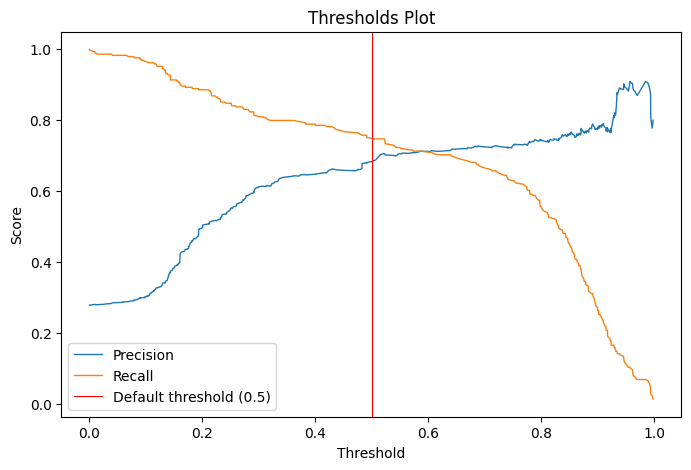

In [26]:
# Reuse the model and test set from the FINAL cross-validation fold (still in memory after the loop)
confidence_score = best_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, confidence_score)

# precision_recall_curve returns one more precision/recall value than thresholds, so we drop the last one
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision", linewidth=1)
plt.plot(thresholds, recall[:-1], label="Recall", linewidth=1)

# Thin red line at the default decision threshold (0.5), as in the paper's figure
plt.axvline(x=0.5, color="red", linewidth=0.8, label="Default threshold (0.5)")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Thresholds Plot")
plt.legend()
plt.show()